<a href="https://colab.research.google.com/github/VSmolin777/Seminar/blob/main/mnist_cnn_lesson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа: Создание CNN на MNIST в Google Colab

**Цель:** Научиться создавать, обучать и оценивать простую сверточную нейронную сеть (CNN) с использованием TensorFlow/Keras в среде Google Colab.

## Шаг 1: Настройка среды и импорт библиотек

Перед началом работы убедитесь, что вы используете среду с GPU для ускорения вычислений.

1.  Зайдите в меню `Runtime` (Среда выполнения) -> `Change runtime type` (Сменить среду выполнения).
2.  В выпадающем списке `Hardware accelerator` (Аппаратный ускоритель) выберите `GPU`.
3.  Нажмите `Save` (Сохранить).

Теперь импортируем все необходимые библиотеки.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.19.0


## Шаг 2: Загрузка и подготовка данных

Мы будем использовать классический датасет MNIST, который встроен прямо в Keras. Он состоит из 60,000 изображений для обучения и 10,000 для тестирования.

Данные нужно подготовить:
1.  **Нормализовать:** значения пикселей находятся в диапазоне от 0 до 255. Для стабильной работы нейросети их лучше привести к диапазону от 0 до 1.
2.  **Изменить форму:** сверточные слои в Keras ожидают на вход тензор определенной формы (высота, ширина, каналы). У нас черно-белые изображения, поэтому канал будет один.
3.  **Преобразовать метки:** метки классов (цифры от 0 до 9) нужно преобразовать в формат one-hot encoding (например, цифра `3` станет вектором `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`).

In [2]:
# Загружаем данные
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Нормализация изображений (приводим к диапазону [0, 1])
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Добавляем канал (из (60000, 28, 28) в (60000, 28, 28, 1))
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Преобразуем метки в one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f'Размер обучающей выборки: {x_train.shape}')
print(f'Размер тестовой выборки: {x_test.shape}')
print(f'Пример метки после преобразования (one-hot): {y_train[0]}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер обучающей выборки: (60000, 28, 28, 1)
Размер тестовой выборки: (10000, 28, 28, 1)
Пример метки после преобразования (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Шаг 3: Создание архитектуры CNN

Теперь создадим саму модель. Мы будем использовать простую архитектуру, состоящую из нескольких ключевых слоев:
- `Conv2D`: Сверточный слой, который ищет паттерны на изображении.
- `MaxPooling2D`: Слой субдискретизации, который уменьшает размер карты признаков, сохраняя наиболее важную информацию.
- `Flatten`: Слой, который 'выпрямляет' многомерные данные в одномерный вектор перед подачей в полносвязные слои.
- `Dense`: Обычный полносвязный слой нейронов.
- `Dropout`: Слой регуляризации для борьбы с переобучением, который случайным образом 'отключает' часть нейронов во время обучения.

In [3]:
model = Sequential([
    # Входной слой: указываем input_shape только для первого слоя
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    # Второй сверточный блок
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Переход к полносвязным слоям
    Flatten(),
    Dropout(0.5), # Слой регуляризации для предотвращения переобучения

    # Полносвязный слой и выходной слой
    Dense(128, activation='relu'),
    Dense(10, activation='softmax') # 10 выходов (для цифр 0-9) с активацией softmax для классификации
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Посмотрим на структуру получившейся модели с помощью метода `summary()`.

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Шаг 4: Компиляция модели

Перед обучением модель нужно 'скомпилировать'. На этом шаге мы определяем:
- `optimizer`: Алгоритм, который будет подстраивать веса модели (например, `adam`).
- `loss`: Функцию потерь, которую модель будет стараться минимизировать (для мультиклассовой классификации это `categorical_crossentropy`).
- `metrics`: Метрики, которые мы хотим отслеживать в процессе обучения (самая популярная — `accuracy`).

In [5]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Шаг 5: Обучение модели

Запускаем процесс обучения с помощью метода `fit()`.

- `epochs`: количество полных проходов по всему обучающему набору данных.
- `batch_size`: количество образцов, которые обрабатываются за одну итерацию.
- `validation_data`: данные, на которых модель будет проверяться после каждой эпохи (не участвуют в обучении).

In [6]:
batch_size = 128
epochs = 3

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test))

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8305 - loss: 0.5354 - val_accuracy: 0.9808 - val_loss: 0.0617
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9713 - loss: 0.0895 - val_accuracy: 0.9866 - val_loss: 0.0401
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9812 - loss: 0.0607 - val_accuracy: 0.9873 - val_loss: 0.0349


## Шаг 6: Оценка качества модели

После обучения оценим финальную точность модели на тестовых данных, которые она никогда не видела.

In [7]:
score = model.evaluate(x_test, y_test, verbose=0)
print(f'Потери на тестовых данных: {score[0]}')
print(f'Точность на тестовых данных: {score[1]}')

Потери на тестовых данных: 0.03489653021097183
Точность на тестовых данных: 0.9872999787330627


## Шаг 7: Визуализация результатов

Построим графики, чтобы увидеть, как менялись точность и потери в процессе обучения. Это помогает понять, не переобучилась ли модель.

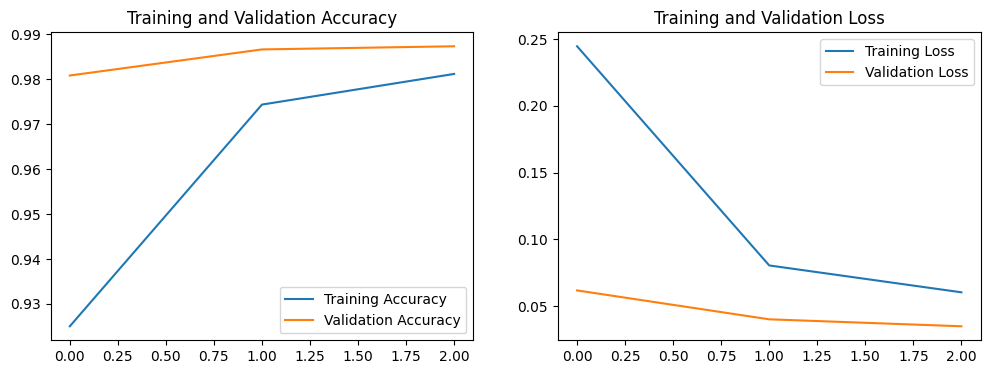

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Шаг 8: Сохранение на GitHub

Теперь, когда у нас есть готовый и работающий блокнот, сохраним его в свое портфолио на GitHub.

1.  В меню Google Colab выберите `File` (Файл) -> `Save a copy in GitHub` (Сохранить копию на GitHub).
2.  Пройдите авторизацию, если потребуется.
3.  Выберите свой репозиторий (или создайте новый).
4.  Убедитесь, что имя файла `mnist_cnn_lesson.ipynb`.
5.  Напишите осмысленный `commit message`, например: `Create CNN for MNIST classification`.
6.  Нажмите `OK`.

**Поздравляем!** Ваш первый ML-проект теперь в вашем портфолио.